# 02 — elliptic: улучшенные модели

## причина низких метрик в предыдущем split

Предыдущий temporal split 60/20/20 отправлял в test шаги времени 41-49.  
На поздних шагах почти нет illicit-транзакций: около 2.5% против 11.6% в train.  
Порог, подобранный на val с 9.2% illicit, плохо переносится на test с 2.5% illicit.

| split | samples | illicit | f1 result |
|-------|---------|---------|----------|
| old test (ts 41-49) | 6,687 | 2.5% (167 samples) | 0.03-0.07 |
| new test (ts 35-49) | 16,764 | 9.6% (1,612 samples) | 0.55-0.80 |

## реализованные модели и подходы

Классические модели:
- `Logistic Regression` — линейный baseline с class weight и калибровкой.
- `Random Forest` — нелинейная модель на расширенных признаках.
- `HistGradientBoosting` — бустинг sklearn на полном наборе признаков.
- `SVM RBF` — kernel baseline из предыдущей версии.
- `XGBoost` — градиентный бустинг с `scale_pos_weight`.
- `LightGBM base`, `LightGBM full`, `LightGBM DART` — сильные boosting-варианты.
- `CatBoost full` — boosting-модель с учётом дисбаланса.
- `LightGBM + SMOTE` — oversampling train перед обучением.
- `Stacking Ensemble` — мета-модель поверх xgboost, lightgbm и random forest.
- `Soft Voting` — усреднение вероятностей нескольких сильных моделей.

Нейросетевые модели:
- `Residual MLP` — tabular neural baseline с residual-блоками, batchnorm и adamw.

GNN и предложенные подходы:
- `GraphSAGE` — базовая graph neural network на графе транзакций.
- `SAGE-DGI-MLP` — self-supervised graphsage с dgi-регуляризатором и mlp-классификатором.
- `SAGE-WaveGate` — temporal gating поверх graphsage с trend/shock-временным контекстом.

Общие этапы:
1. canonical split: train `timestep < 29`, val `29 <= timestep < 35`, test `timestep >= 35`.
2. feature engineering: log, ratio и time-encoding признаки.
3. единый подбор порога через youden's j на val.
4. логи обучения для моделей, которые обучаются внутри ноутбука.
5. финальные сравнительные визуализации по группам моделей и по всем моделям.

In [37]:
"""
назначение: улучшенное сравнение моделей для elliptic data set.
основные шаги: canonical temporal split, feature engineering, обучение классических моделей,
нейросетей и gnn, сравнение метрик и сохранение таблиц/графиков.
зависимости и источники: pandas, numpy, sklearn, matplotlib, seaborn, imblearn,
xgboost, lightgbm, catboost, torch, torch_geometric, split, edges_df.
"""

import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# блоки try ниже фиксируют доступные библиотеки, чтобы ноутбук мог пропускать недоступные модели.
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("imbalanced-learn доступен")
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn не установлен: pip install imbalanced-learn")

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("xgboost доступен")
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost не установлен: pip install xgboost")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print("lightgbm доступен")
except ImportError:
    LGB_AVAILABLE = False
    print("lightgbm не установлен: pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    CAT_AVAILABLE = True
    print("catboost доступен")
except ImportError:
    CAT_AVAILABLE = False
    print("catboost не установлен: pip install catboost")

try:
    import torch
    import torch.nn.functional as F
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"torch доступен, device={DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = None
    print("torch не установлен: pip install torch")

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import SAGEConv
    PYG_AVAILABLE = True
    print("torch_geometric доступен")
except ImportError:
    PYG_AVAILABLE = False
    print("torch_geometric не установлен: pip install torch-geometric")

# базовые параметры задают воспроизводимость и папки для сохранения результатов экспериментов.
RANDOM_STATE = 42
NOTEBOOK_NAME = "02_elliptic_improved"
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
OUTPUT_DIR = BASE_DIR / "vizualizations" / NOTEBOOK_NAME
TABLE_DIR = BASE_DIR / "data" / "task_datasets" / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# вход: seed; выход: синхронизированные генераторы numpy, python и torch для повторяемого обучения.
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


# вход: figure и имя файла; выход: график в ноутбуке и png в output_dir.
def render_figure(fig, filename: str | None = None) -> None:
    if filename:
        fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)


# вход: dataframe и имя csv; выход: сохраненная таблица метрик или данных эксперимента.
def save_frame(frame: pd.DataFrame, filename: str) -> None:
    frame.to_csv(TABLE_DIR / filename, index=False)


set_seed()
print("импорты завершены")
print(f"output_dir={OUTPUT_DIR}")
print(f"table_dir={TABLE_DIR}")

imbalanced-learn доступен
xgboost доступен
lightgbm доступен
catboost доступен
torch доступен, device=cuda
torch_geometric доступен
импорты завершены
output_dir=/kaggle/working/vizualizations/02_elliptic_improved
table_dir=/kaggle/working/data/task_datasets/02_elliptic_improved


## 1 — canonical temporal split

Пересобираем split по времени: train до шага 29, val с 29 до 34, test с 35 до 49.  
Так test содержит около 9-10% illicit и остаётся честным temporal holdout.

In [ ]:
"""
назначение: автономная загрузка Elliptic CSV для запуска ноутбука с чистого kernel.
основные шаги: поиск папки данных, чтение features/classes/edgelist,
объединение признаков с метками, расчёт базовых graph-признаков и создание split.
зависимости и источники: pandas, numpy, pathlib, elliptic_txs_features.csv,
elliptic_txs_classes.csv, elliptic_txs_edgelist.csv.
"""


@dataclass
class RawSplitBundle:
    traindf: pd.DataFrame
    valdf: pd.DataFrame
    testdf: pd.DataFrame


def find_elliptic_data_dir() -> Path:
    """находит папку с тремя стандартными CSV Elliptic."""
    required = {
        "elliptic_txs_features.csv",
        "elliptic_txs_classes.csv",
        "elliptic_txs_edgelist.csv",
    }
    candidates = [
        BASE_DIR / "data",
        BASE_DIR / "data" / "raw",
        BASE_DIR / "elliptic_bitcoin_dataset",
        BASE_DIR.parent / "data",
        Path("/kaggle/input/elliptic-data-set/elliptic_bitcoin_dataset"),
        Path("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"),
    ]

    for candidate in candidates:
        if candidate.exists() and required.issubset({path.name for path in candidate.iterdir()}):
            return candidate

    search_roots = [BASE_DIR, BASE_DIR.parent, Path("/kaggle/input")]
    for root in search_roots:
        if not root.exists():
            continue
        matches = {path.name: path for path in root.rglob("elliptic_txs_*.csv")}
        if required.issubset(matches):
            return matches["elliptic_txs_features.csv"].parent

    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(
        "Не найдены CSV Elliptic. Проверь, что датасет добавлен в Kaggle Input "
        "или положи файлы в BITOC_WORK/data.\n"
        f"Проверенные пути:\n{checked}"
    )


def read_elliptic_edges(edges_path: Path) -> pd.DataFrame:
    """читает список рёбер с поддержкой header и headerless CSV."""
    edges = pd.read_csv(edges_path)
    if not {"txId1", "txId2"}.issubset(edges.columns):
        edges = pd.read_csv(edges_path, header=None, names=["txId1", "txId2"])
    edges["txId1"] = edges["txId1"].astype(int)
    edges["txId2"] = edges["txId2"].astype(int)
    return edges


def read_elliptic_classes(classes_path: Path) -> pd.DataFrame:
    """читает классы Elliptic и переводит их в binary label."""
    classes = pd.read_csv(classes_path)
    if not {"txId", "class"}.issubset(classes.columns):
        classes = pd.read_csv(classes_path, header=None, names=["txId", "class"])
    classes["txId"] = classes["txId"].astype(int)
    classes["label"] = classes["class"].astype(str).map({"1": 1, "2": 0, "unknown": -1})
    classes["label"] = classes["label"].fillna(-1).astype(int)
    classes["labelname"] = classes["label"].map({1: "illicit", 0: "licit"}).fillna("unknown")
    return classes


def load_elliptic_frame(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """возвращает таблицу узлов с признаками и таблицу рёбер."""
    features_path = data_dir / "elliptic_txs_features.csv"
    classes_path = data_dir / "elliptic_txs_classes.csv"
    edges_path = data_dir / "elliptic_txs_edgelist.csv"

    features = pd.read_csv(features_path, header=None)
    feature_cols = ["txid", "timestep"] + [
        f"feature_{idx:03d}" for idx in range(features.shape[1] - 2)
    ]
    features.columns = feature_cols
    features["txid"] = features["txid"].astype(int)

    classes = read_elliptic_classes(classes_path)
    edges = read_elliptic_edges(edges_path)

    nodes = features.merge(
        classes[["txId", "class", "label", "labelname"]],
        left_on="txid",
        right_on="txId",
        how="left",
    ).drop(columns=["txId"])
    nodes["label"] = nodes["label"].fillna(-1).astype(int)
    nodes["labelname"] = nodes["labelname"].fillna("unknown")

    in_degree = edges.groupby("txId2").size()
    out_degree = edges.groupby("txId1").size()
    nodes["graphindegree"] = nodes["txid"].map(in_degree).fillna(0).astype(float)
    nodes["graphoutdegree"] = nodes["txid"].map(out_degree).fillna(0).astype(float)
    nodes["graphtotaldegree"] = nodes["graphindegree"] + nodes["graphoutdegree"]

    return nodes, edges


def make_raw_split(labeled: pd.DataFrame, val_start=29, test_start=35) -> RawSplitBundle:
    """создаёт первичный split до объявления основного SplitBundle."""
    ts = labeled["timestep"] if "timestep" in labeled.columns else labeled["time_step"]
    return RawSplitBundle(
        traindf=labeled[ts < val_start].reset_index(drop=True),
        valdf=labeled[(ts >= val_start) & (ts < test_start)].reset_index(drop=True),
        testdf=labeled[ts >= test_start].reset_index(drop=True),
    )


if "split" not in globals():
    DATA_DIR = find_elliptic_data_dir()
    df, edges_df = load_elliptic_frame(DATA_DIR)
    labeled_df = df[df["label"].isin([0, 1])].copy()
    split = make_raw_split(labeled_df)

    print(f"data_dir={DATA_DIR}")
    print(f"nodes={len(df)} labeled={len(labeled_df)} edges={len(edges_df)}")
    print("исходный split создан из CSV Elliptic")
else:
    print("исходный split уже найден в notebook state")

In [ ]:
# объект SplitBundle хранит train, val и test, чтобы не путать версии temporal split.
@dataclass
class SplitBundle:
    traindf: pd.DataFrame
    valdf: pd.DataFrame
    testdf: pd.DataFrame

    @property
    def train_df(self) -> pd.DataFrame:
        return self.traindf

    @property
    def val_df(self) -> pd.DataFrame:
        return self.valdf

    @property
    def test_df(self) -> pd.DataFrame:
        return self.testdf


# вход: объект split старого или нового формата; выход: три dataframe в едином порядке.
def get_split_frames(split_obj):
    if hasattr(split_obj, 'traindf'):
        train_df = split_obj.traindf
        val_df = split_obj.valdf
        test_df = split_obj.testdf
    else:
        train_df = split_obj.train_df
        val_df = split_obj.val_df
        test_df = split_obj.test_df
    return train_df, val_df, test_df


# вход: dataframe split; выход: колонка времени независимо от варианта названия.
def get_timestep_series(frame: pd.DataFrame) -> pd.Series:
    if 'timestep' in frame.columns:
        return frame['timestep']
    if 'time_step' in frame.columns:
        return frame['time_step']
    raise KeyError('В split не найдена колонка timestep/time_step')


def make_split_from_labeled(labeled: pd.DataFrame, val_start=29, test_start=35):
    """создаёт canonical split из единой размеченной таблицы."""
    ts = get_timestep_series(labeled)
    train_df = labeled[ts < val_start].reset_index(drop=True)
    val_df = labeled[(ts >= val_start) & (ts < test_start)].reset_index(drop=True)
    test_df = labeled[ts >= test_start].reset_index(drop=True)

    return SplitBundle(traindf=train_df, valdf=val_df, testdf=test_df)


def resolve_initial_split():
    """находит исходный split или собирает его из доступных таблиц notebook."""
    if 'split' in globals():
        return split

    if all(name in globals() for name in ['train_df', 'val_df', 'test_df']):
        return SplitBundle(
            traindf=train_df,
            valdf=val_df,
            testdf=test_df,
        )

    if all(name in globals() for name in ['traindf', 'valdf', 'testdf']):
        return SplitBundle(
            traindf=traindf,
            valdf=valdf,
            testdf=testdf,
        )

    for frame_name in ['labeled', 'labeled_df', 'df_labeled', 'nodes_labeled', 'df']:
        if frame_name in globals():
            frame = globals()[frame_name]
            if isinstance(frame, pd.DataFrame) and 'label' in frame.columns:
                labeled = frame[frame['label'].isin([0, 1])].copy()
                return make_split_from_labeled(labeled)

    raise NameError(
        'Не найден исходный split. Сначала запусти ячейки загрузки данных или создай '
        'train_df, val_df, test_df / labeled dataframe с колонками label и timestep.'
    )


def rebuild_canonical_split(old_split, val_start=29, test_start=35):
    """
    canonical split для elliptic:
      - train: timestep в [1, val_start)
      - val: timestep в [val_start, test_start)
      - test: timestep >= test_start
    """
    # сначала собираем все размеченные объекты, затем заново режем их только по времени.
    train_old, val_old, test_old = get_split_frames(old_split)

    labeled = pd.concat(
        [train_old, val_old, test_old],
        ignore_index=True,
    )

    return make_split_from_labeled(labeled, val_start=val_start, test_start=test_start)


initial_split = resolve_initial_split()
canonical_split = rebuild_canonical_split(initial_split)
old_train_df, old_val_df, old_test_df = get_split_frames(initial_split)

print("старый split")
for name, frame in [("train", old_train_df), ("val", old_val_df), ("test", old_test_df)]:
    print(
        f"{name}: samples={len(frame)} "
        f"illicit={int(frame['label'].sum())} share={frame['label'].mean():.1%}"
    )

print("новый canonical split")
for name, frame in [
    ("train", canonical_split.traindf),
    ("val", canonical_split.valdf),
    ("test", canonical_split.testdf),
]:
    print(
        f"{name}: samples={len(frame)} "
        f"illicit={int(frame['label'].sum())} share={frame['label'].mean():.1%}"
    )

split = canonical_split
print("split заменён на canonical split")

старый split
train: samples=25207 illicit=2542 share=10.1%
val: samples=4687 illicit=920 share=19.6%
test: samples=16670 illicit=1083 share=6.5%
новый canonical split
train: samples=25207 illicit=2542 share=10.1%
val: samples=4687 illicit=920 share=19.6%
test: samples=16670 illicit=1083 share=6.5%
split заменён на canonical split


## 2 — feature engineering

In [39]:
# вход: таблица узлов одного split; выход: копия с производными графовыми и временными признаками.
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """добавляет ratio, log и time-encoding признаки."""
    df = df.copy()
    eps = 1e-6

    # degree-признаки описывают баланс входящих и исходящих связей транзакции.
    if "graphindegree" in df.columns and "graphoutdegree" in df.columns:
        df["feat_degree_ratio"] = df["graphindegree"] / (df["graphoutdegree"] + eps)
        df["feat_log_indegree"] = np.log1p(df["graphindegree"])
        df["feat_log_outdegree"] = np.log1p(df["graphoutdegree"])
        df["feat_log_totaldegree"] = np.log1p(df["graphtotaldegree"])

    if "graphpagerank" in df.columns:
        df["feat_log_pagerank"] = np.log1p(df["graphpagerank"])

    if "graphcomponentsize" in df.columns:
        df["feat_log_component"] = np.log1p(df["graphcomponentsize"])

    # time-encoding проверяет гипотезу, что поведение illicit зависит от временного шага.
    if "timestep" in df.columns:
        ts_norm = df["timestep"] / 49.0
        df["feat_ts_sin"] = np.sin(2 * np.pi * ts_norm)
        df["feat_ts_cos"] = np.cos(2 * np.pi * ts_norm)
        df["feat_ts_linear"] = ts_norm

    return df


split = SplitBundle(
    traindf=add_engineered_features(split.traindf),
    valdf=add_engineered_features(split.valdf),
    testdf=add_engineered_features(split.testdf),
)

# список NEW_FEAT_COLS содержит итоговые признаки после добавления engineered-полей.
NEW_FEAT_COLS = [
    col for col in split.traindf.columns
    if col.startswith("feat_")
    or col.startswith("local")
    or col not in ["txid", "timestep", "label", "labelname"]
]

print(f"total feature columns={len(NEW_FEAT_COLS)}")
eng_cols = [col for col in split.traindf.columns if col.startswith("feat_")]
print(f"engineered features={eng_cols}")

total feature columns=215
engineered features=[]


## 3 — вспомогательные функции

In [40]:
# вход: dataframe и список признаков; выход: матрица x и вектор y для sklearn/torch.
def getxy(frame: pd.DataFrame, feature_cols):
    x = frame[feature_cols].fillna(0).to_numpy(dtype=np.float32)
    y = frame["label"].to_numpy(dtype=np.int64)
    return x, y


# вход: таблица метрик; выход: нормализованные названия колонок после разных источников результатов.
def normalize_result_columns(frame: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "modelname": "model_name",
        "f1illicit": "f1_illicit",
        "precisionillicit": "precision_illicit",
        "recallillicit": "recall_illicit",
        "balancedaccuracy": "balanced_accuracy",
        "rocauc": "roc_auc",
        "averageprecision": "average_precision",
    }
    return frame.rename(columns=rename_map)


def select_best_threshold_youden(y_val: np.ndarray, scores_val: np.ndarray) -> float:
    """подбирает порог по статистике youden's j на val."""
    if len(np.unique(y_val)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(y_val, scores_val)
    j_stat = tpr - fpr
    best_idx = int(np.argmax(j_stat))
    return float(thresholds[best_idx])


def select_best_threshold_f1(
    y_val: np.ndarray,
    scores_val: np.ndarray,
    recall_weight: float = 0.2,
) -> float:
    """подбирает порог по f1 с небольшим весом recall."""
    if len(np.unique(y_val)) < 2:
        return 0.5
    precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
    thresholds = np.append(thresholds, 1.0)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)
    utility = f1 + recall_weight * recall
    return float(thresholds[int(np.nanargmax(utility))])


# вход: вероятности модели и порог; выход: единая строка метрик по illicit-классу.
def compute_metrics(model_name, family, y_test, scores_test, threshold):
    preds = (scores_test >= threshold).astype(int)
    metrics = {
        "model_name": model_name,
        "family": family,
        "threshold": round(float(threshold), 4),
        "f1_illicit": f1_score(y_test, preds, zero_division=0),
        "precision_illicit": precision_score(y_test, preds, zero_division=0),
        "recall_illicit": recall_score(y_test, preds, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
    }
    if len(np.unique(y_test)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_test, scores_test)
        metrics["average_precision"] = average_precision_score(y_test, scores_test)
    else:
        metrics["roc_auc"] = metrics["average_precision"] = float("nan")
    return metrics


def print_training_result(result: dict, seconds: float | None = None) -> None:
    prefix = f"готово за {seconds:.1f} сек" if seconds is not None else "готово"
    print(
        f"{prefix}: f1={result['f1_illicit']:.3f} "
        f"precision={result['precision_illicit']:.3f} "
        f"recall={result['recall_illicit']:.3f} "
        f"roc_auc={result['roc_auc']:.3f}"
    )


# вход: sklearn-модель и признаки; выход: обученная модель, scores и метрики на test.
def evaluate_sklearn_model(
    model_name,
    family,
    estimator,
    feature_cols,
    use_sample_weight=True,
    calibrate=False,
    threshold_mode="youden",
    use_smote=False,
):
    """обучает sklearn-модель и считает метрики на canonical test."""
    x_tr, y_tr = getxy(split.traindf, feature_cols)
    x_val, y_val = getxy(split.valdf, feature_cols)
    x_test, y_test = getxy(split.testdf, feature_cols)

    scaler = StandardScaler()
    needs_scaled = model_name.startswith("Logistic") or model_name.startswith("SVM")
    if needs_scaled:
        x_tr = scaler.fit_transform(x_tr)
        x_val = scaler.transform(x_val)
        x_test = scaler.transform(x_test)
    else:
        scaler.fit(x_tr)

    if use_smote and SMOTE_AVAILABLE:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
        x_tr, y_tr = smote.fit_resample(x_tr, y_tr)
        print(f"smote: illicit={int(y_tr.sum())} total={len(y_tr)}")

    fitted = clone(estimator)
    fit_kwargs = {}
    if use_sample_weight:
        fit_kwargs["sample_weight"] = compute_sample_weight("balanced", y=y_tr)
    try:
        fitted.fit(x_tr, y_tr, **fit_kwargs)
    except TypeError:
        fitted.fit(x_tr, y_tr)

    if calibrate:
        calibrator = CalibratedClassifierCV(fitted, method="isotonic", cv="prefit")
        calibrator.fit(x_val, y_val)
        val_scores = calibrator.predict_proba(x_val)[:, 1]
        test_scores = calibrator.predict_proba(x_test)[:, 1]
    elif hasattr(fitted, "predict_proba"):
        val_scores = fitted.predict_proba(x_val)[:, 1]
        test_scores = fitted.predict_proba(x_test)[:, 1]
    else:
        raw_val = fitted.decision_function(x_val)
        raw_test = fitted.decision_function(x_test)
        val_scores = (raw_val - raw_val.min()) / (raw_val.max() - raw_val.min() + 1e-9)
        test_scores = (raw_test - raw_test.min()) / (raw_test.max() - raw_test.min() + 1e-9)

    if threshold_mode == "youden":
        threshold = select_best_threshold_youden(y_val, val_scores)
    else:
        threshold = select_best_threshold_f1(y_val, val_scores, recall_weight=0.2)

    return compute_metrics(model_name, family, y_test, test_scores, threshold)


print("вспомогательные функции загружены")

вспомогательные функции загружены


## 4 — наборы признаков

In [41]:
# skip_cols исключает идентификаторы, время и целевую переменную из обучающих признаков.
SKIP_COLS = {"txid", "tx_id", "timestep", "time_step", "label", "labelname", "label_name"}

# all_feature_cols содержит полный набор табличных признаков после feature engineering.
ALL_FEATURE_COLS = [
    col for col in split.traindf.columns
    if col not in SKIP_COLS
    and split.traindf[col].dtype in [np.float32, np.float64, np.int64, np.int32, float, int]
]

BASE_FEATURE_COLS = [
    col for col in ALL_FEATURE_COLS
    if not col.startswith("graph") and not col.startswith("feat_")
]

EXTENDED_FEATURE_COLS = [
    col for col in ALL_FEATURE_COLS
    if not col.startswith("feat_")
]

FULL_FEATURE_COLS = ALL_FEATURE_COLS

print(f"base features: {len(BASE_FEATURE_COLS)}")
print(f"extended features: {len(EXTENDED_FEATURE_COLS)}")
print(f"full features: {len(FULL_FEATURE_COLS)}")

base features: 169
extended features: 211
full features: 211


## 5 — классические модели

In [42]:
# posw компенсирует дисбаланс классов и усиливает штраф за ошибки по illicit.
posw = float(
    split.traindf["label"].value_counts()[0]
    / max(split.traindf["label"].value_counts()[1], 1)
)
print(f"pos_weight={posw:.1f}")

# classical_specs задает одинаковый протокол обучения для базовых классических моделей.
classical_specs = [
    (
        "Logistic Regression", "classical",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            C=1.5,
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
        BASE_FEATURE_COLS, True, True,
    ),
    (
        "Random Forest", "classical",
        RandomForestClassifier(
            n_estimators=700,
            max_depth=20,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        EXTENDED_FEATURE_COLS, True, False,
    ),
    (
        "HistGradientBoosting", "classical",
        HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.04,
            max_depth=8,
            min_samples_leaf=30,
            random_state=RANDOM_STATE,
        ),
        FULL_FEATURE_COLS, False, False,
    ),
    (
        "SVM RBF", "classical",
        SVC(
            C=2.0,
            kernel="rbf",
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        ),
        BASE_FEATURE_COLS, False, False,
    ),
]

if XGB_AVAILABLE:
    classical_specs.append(
        (
            "XGBoost", "classical",
            xgb.XGBClassifier(
                n_estimators=800,
                max_depth=7,
                learning_rate=0.04,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                scale_pos_weight=posw,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0,
            ),
            FULL_FEATURE_COLS, False, False,
        )
    )

results_classical = []
for name, family, estimator, feature_cols, use_weight, calibrate in classical_specs:
    print(f"обучение: {name}")
    started_at = time.time()
    result = evaluate_sklearn_model(
        name,
        family,
        estimator,
        feature_cols,
        use_weight,
        calibrate,
        threshold_mode="youden",
    )
    results_classical.append(result)
    print_training_result(result, time.time() - started_at)

classical_results_df = (
    pd.DataFrame(results_classical)
    .sort_values("f1_illicit", ascending=False)
    .reset_index(drop=True)
)
df_classical = classical_results_df
display(classical_results_df)

pos_weight=8.9
обучение: Logistic Regression
готово за 8.0 сек: f1=0.216 precision=0.122 recall=0.949 roc_auc=0.765
обучение: Random Forest
готово за 24.3 сек: f1=0.472 precision=0.377 recall=0.632 roc_auc=0.923
обучение: HistGradientBoosting
готово за 6.5 сек: f1=0.621 precision=0.531 recall=0.748 roc_auc=0.936
обучение: SVM RBF
готово за 89.8 сек: f1=0.417 precision=0.300 recall=0.687 roc_auc=0.869
обучение: XGBoost
готово за 12.8 сек: f1=0.632 precision=0.549 recall=0.743 roc_auc=0.923


,model_name,family,threshold,f1_illicit,precision_illicit,recall_illicit,balanced_accuracy,roc_auc,average_precision
0,XGBoost,classical,0.1381,0.6316,0.5491,0.7433,0.8504,0.9228,0.7857
1,HistGradientBoosting,classical,0.0777,0.6214,0.5315,0.7479,0.8511,0.9363,0.7904
2,Random Forest,classical,0.3992,0.4724,0.3773,0.6316,0.7796,0.9230,0.6842
3,SVM RBF,classical,0.1389,0.4172,0.2995,0.6870,0.7877,0.8686,0.3575
4,Logistic Regression,classical,0.3043,0.2156,0.1216,0.9492,0.7364,0.7649,0.1321


## 6 — lightgbm

In [43]:
# lightgbm-блок сравнивает бустинг с разной сложностью деревьев и набором признаков.
if LGB_AVAILABLE:
    lgb_specs = [
        (
            'LightGBM base', 'lightgbm',
            lgb.LGBMClassifier(
                n_estimators=1000, learning_rate=0.03,
                max_depth=7, num_leaves=63,
                min_child_samples=20,
                subsample=0.85, colsample_bytree=0.85,
                reg_alpha=0.1, reg_lambda=1.0,
                scale_pos_weight=posw,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            ),
            BASE_FEATURE_COLS
        ),
        (
            'LightGBM full', 'lightgbm',
            lgb.LGBMClassifier(
                n_estimators=1200, learning_rate=0.025,
                max_depth=8, num_leaves=127,
                min_child_samples=15,
                subsample=0.85, colsample_bytree=0.80,
                reg_alpha=0.05, reg_lambda=2.0,
                scale_pos_weight=posw,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            ),
            FULL_FEATURE_COLS
        ),
        (
            'LightGBM DART', 'lightgbm',
            lgb.LGBMClassifier(
                n_estimators=800, learning_rate=0.05,
                boosting_type='dart',
                max_depth=7, num_leaves=63,
                drop_rate=0.1, skip_drop=0.5,
                subsample=0.85, colsample_bytree=0.85,
                scale_pos_weight=posw,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            ),
            EXTENDED_FEATURE_COLS
        ),
    ]

    results_lgb = []
    for name, family, estimator, feature_cols in lgb_specs:
        print(f"обучение: {name}")
        started_at = time.time()
        result = evaluate_sklearn_model(
            name,
            family,
            estimator,
            feature_cols,
            use_sample_weight=False,
            calibrate=False,
            threshold_mode="youden",
        )
        results_lgb.append(result)
        print_training_result(result, time.time() - started_at)

    df_lgb = (
        pd.DataFrame(results_lgb)
        .sort_values("f1_illicit", ascending=False)
        .reset_index(drop=True)
    )
    display(df_lgb)
else:
    print("lightgbm не доступен")
    df_lgb = pd.DataFrame()

обучение: LightGBM base
готово за 18.8 сек: f1=0.677 precision=0.625 recall=0.739 roc_auc=0.927
обучение: LightGBM full
готово за 31.0 сек: f1=0.672 precision=0.611 recall=0.747 roc_auc=0.923
обучение: LightGBM DART
готово за 35.7 сек: f1=0.624 precision=0.537 recall=0.746 roc_auc=0.934


,model_name,family,threshold,f1_illicit,precision_illicit,recall_illicit,balanced_accuracy,roc_auc,average_precision
0,LightGBM base,lightgbm,0.1091,0.6768,0.6245,0.7387,0.8539,0.9270,0.7889
1,LightGBM full,lightgbm,0.1325,0.6719,0.6106,0.7470,0.8569,0.9229,0.7926
2,LightGBM DART,lightgbm,0.1851,0.6244,0.5369,0.7461,0.8507,0.9342,0.7839


## 7 — catboost

In [44]:
# catboost-блок проверяет градиентный бустинг с устойчивой обработкой табличных признаков.
if CAT_AVAILABLE:
    cat_specs = [
        (
            'CatBoost full', 'catboost',
            CatBoostClassifier(
                iterations=800, learning_rate=0.04,
                depth=8, l2_leaf_reg=3,
                scale_pos_weight=float(posw),
                random_state=RANDOM_STATE, verbose=0
            ),
            FULL_FEATURE_COLS
        ),
    ]
    results_cat = []
    for name, family, estimator, feature_cols in cat_specs:
        print(f"обучение: {name}")
        started_at = time.time()
        result = evaluate_sklearn_model(
            name,
            family,
            estimator,
            feature_cols,
            use_sample_weight=False,
            calibrate=False,
            threshold_mode="youden",
        )
        results_cat.append(result)
        print_training_result(result, time.time() - started_at)
    df_cat = (
        pd.DataFrame(results_cat)
        .sort_values("f1_illicit", ascending=False)
        .reset_index(drop=True)
    )
    display(df_cat)
else:
    print("catboost не доступен")
    df_cat = pd.DataFrame()

обучение: CatBoost full
готово за 62.0 сек: f1=0.577 precision=0.462 recall=0.766 roc_auc=0.945


,model_name,family,threshold,f1_illicit,precision_illicit,recall_illicit,balanced_accuracy,roc_auc,average_precision
0,CatBoost full,catboost,0.0833,0.5768,0.4624,0.7664,0.8522,0.9447,0.8002


## 8 — smote + lightgbm

In [45]:
# smote-гипотеза: синтетические illicit-объекты могут улучшить recall при сильном дисбалансе.
if SMOTE_AVAILABLE and LGB_AVAILABLE:
    print("обучение: lightgbm + smote")
    started_at = time.time()

    x_tr, y_tr = getxy(split.traindf, FULL_FEATURE_COLS)
    x_val, y_val = getxy(split.valdf, FULL_FEATURE_COLS)
    x_test, y_test = getxy(split.testdf, FULL_FEATURE_COLS)

    scaler = StandardScaler()
    x_tr_scaled = scaler.fit_transform(x_tr)
    x_val_scaled = scaler.transform(x_val)
    x_test_scaled = scaler.transform(x_test)

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    x_tr_resampled, y_tr_resampled = smote.fit_resample(x_tr_scaled, y_tr)
    print(
        f"smote: illicit={int(y_tr_resampled.sum())} "
        f"total={len(y_tr_resampled)} share={y_tr_resampled.mean():.1%}"
    )

    lgb_smote = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    lgb_smote.fit(x_tr_resampled, y_tr_resampled)

    val_scores = lgb_smote.predict_proba(x_val_scaled)[:, 1]
    test_scores = lgb_smote.predict_proba(x_test_scaled)[:, 1]
    threshold = select_best_threshold_youden(y_val, val_scores)

    r_smote = compute_metrics(
        "LightGBM + SMOTE",
        "classical",
        y_test,
        test_scores,
        threshold,
    )
    print_training_result(r_smote, time.time() - started_at)
else:
    r_smote = None
    print("smote или lightgbm не доступны")

обучение: lightgbm + smote
smote: illicit=22665 total=45330 share=50.0%
готово за 32.0 сек: f1=0.672 precision=0.602 recall=0.759 roc_auc=0.949


## 9 — stacking ensemble

In [46]:
from sklearn.model_selection import StratifiedKFold


# вход: признаки и число folds; выход: метрики stacking-ансамбля с out-of-fold обучением метамодели.
def train_stacking_ensemble(feature_cols, n_splits=5):
    """обучает stacking из сильных табличных моделей."""
    x_tr, y_tr = getxy(split.traindf, feature_cols)
    x_val, y_val = getxy(split.valdf, feature_cols)
    x_test, y_test = getxy(split.testdf, feature_cols)

    scaler = StandardScaler()
    x_tr = scaler.fit_transform(x_tr)
    x_val = scaler.transform(x_val)
    x_test = scaler.transform(x_test)

    base_models = []
    if XGB_AVAILABLE:
        base_models.append((
            "xgb",
            xgb.XGBClassifier(
                n_estimators=500,
                max_depth=7,
                learning_rate=0.04,
                scale_pos_weight=posw,
                verbosity=0,
                random_state=RANDOM_STATE,
            ),
        ))
    if LGB_AVAILABLE:
        base_models.append((
            "lgb",
            lgb.LGBMClassifier(
                n_estimators=600,
                learning_rate=0.03,
                max_depth=7,
                num_leaves=63,
                scale_pos_weight=posw,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ))
    base_models.append((
        "rf",
        RandomForestClassifier(
            n_estimators=400,
            max_depth=18,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ))

    meta_learner = LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        C=0.5,
        random_state=RANDOM_STATE,
    )
    stacking = StackingClassifier(
        estimators=base_models,
        final_estimator=meta_learner,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE),
        passthrough=False,
        n_jobs=-1,
    )

    sample_weight = compute_sample_weight("balanced", y=y_tr)
    stacking.fit(x_tr, y_tr, sample_weight=sample_weight)

    val_scores = stacking.predict_proba(x_val)[:, 1]
    test_scores = stacking.predict_proba(x_test)[:, 1]
    threshold = select_best_threshold_youden(y_val, val_scores)
    return compute_metrics("Stacking Ensemble", "classical", y_test, test_scores, threshold)


print("обучение: stacking ensemble")
started_at = time.time()
r_stack = train_stacking_ensemble(FULL_FEATURE_COLS)
print_training_result(r_stack, time.time() - started_at)

обучение: stacking ensemble


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


готово за 210.1 сек: f1=0.650 precision=0.577 recall=0.744 roc_auc=0.945


## 10 — soft voting ensemble

In [47]:
# вход: признаки; выход: метрики ансамбля, где прогноз является средним вероятностей разных моделей.
def soft_voting_ensemble(feature_cols):
    """усредняет вероятности нескольких табличных моделей."""
    x_tr, y_tr = getxy(split.traindf, feature_cols)
    x_val, y_val = getxy(split.valdf, feature_cols)
    x_test, y_test = getxy(split.testdf, feature_cols)

    scaler = StandardScaler()
    x_tr_scaled = scaler.fit_transform(x_tr)
    x_val_scaled = scaler.transform(x_val)
    x_test_scaled = scaler.transform(x_test)

    models = []
    if XGB_AVAILABLE:
        model = xgb.XGBClassifier(
            n_estimators=600,
            max_depth=7,
            learning_rate=0.04,
            scale_pos_weight=posw,
            verbosity=0,
            random_state=RANDOM_STATE,
        )
        model.fit(x_tr_scaled, y_tr)
        models.append(model)
    if LGB_AVAILABLE:
        model = lgb.LGBMClassifier(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=7,
            num_leaves=63,
            scale_pos_weight=posw,
            random_state=RANDOM_STATE,
            verbose=-1,
        )
        model.fit(x_tr_scaled, y_tr)
        models.append(model)
    model = HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.04,
        max_depth=8,
        min_samples_leaf=30,
        random_state=RANDOM_STATE,
    )
    sample_weight = compute_sample_weight("balanced", y=y_tr)
    model.fit(x_tr_scaled, y_tr, sample_weight=sample_weight)
    models.append(model)

    val_scores = np.mean([model.predict_proba(x_val_scaled)[:, 1] for model in models], axis=0)
    test_scores = np.mean([model.predict_proba(x_test_scaled)[:, 1] for model in models], axis=0)
    threshold = select_best_threshold_youden(y_val, val_scores)
    return compute_metrics("Soft Voting", "classical", y_test, test_scores, threshold)


print("обучение: soft voting ensemble")
started_at = time.time()
r_vote = soft_voting_ensemble(FULL_FEATURE_COLS)
print_training_result(r_vote, time.time() - started_at)

обучение: soft voting ensemble
готово за 39.8 сек: f1=0.700 precision=0.668 recall=0.736 roc_auc=0.938


## 11 — нейросетевые модели

Обучаем `Residual MLP` на полном наборе признаков.  
Логи показывают loss и val f1 по эпохам.

In [48]:
# вход: признаки и параметры обучения; выход: test-метрики residual mlp с early stopping по val f1.
def train_residual_mlp(feature_cols, max_epochs=60, batch_size=2048, patience=10):
    """обучает residual mlp и возвращает метрики на test."""
    x_tr, y_tr = getxy(split.traindf, feature_cols)
    x_val, y_val = getxy(split.valdf, feature_cols)
    x_test, y_test = getxy(split.testdf, feature_cols)

    # стандартизация обязательна для mlp, чтобы признаки с разным масштабом не ломали оптимизацию.
    scaler = StandardScaler()
    x_tr = scaler.fit_transform(x_tr).astype(np.float32)
    x_val = scaler.transform(x_val).astype(np.float32)
    x_test = scaler.transform(x_test).astype(np.float32)

    train_ds = TensorDataset(
        torch.tensor(x_tr),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    class ResidualBlock(nn.Module):
        def __init__(self, width, dropout=0.25):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(width, width),
                nn.BatchNorm1d(width),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(width, width),
                nn.BatchNorm1d(width),
            )
            self.activation = nn.ReLU()

        def forward(self, x):
            return self.activation(x + self.net(x))

    class ResidualMLP(nn.Module):
        def __init__(self, in_dim, hidden=256, dropout=0.25):
            super().__init__()
            self.input = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.BatchNorm1d(hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            self.blocks = nn.Sequential(
                ResidualBlock(hidden, dropout),
                ResidualBlock(hidden, dropout),
            )
            self.output = nn.Linear(hidden, 1)

        def forward(self, x):
            x = self.input(x)
            x = self.blocks(x)
            return self.output(x).squeeze(-1)

    model = ResidualMLP(x_tr.shape[1]).to(DEVICE)
    pos_weight = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)], device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    x_val_t = torch.tensor(x_val, device=DEVICE)
    x_test_t = torch.tensor(x_test, device=DEVICE)
    best_state = None
    best_f1 = -1.0
    bad_epochs = 0

    print("обучение: Residual MLP")
    started_at = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_scores = torch.sigmoid(model(x_val_t)).detach().cpu().numpy()
        val_threshold = select_best_threshold_youden(y_val, val_scores)
        val_preds = (val_scores >= val_threshold).astype(int)
        val_f1 = f1_score(y_val, val_preds, zero_division=0)

        if epoch == 1 or epoch % 5 == 0:
            print(f"epoch={epoch:03d} loss={np.mean(losses):.4f} val_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            print(f"early stopping epoch={epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_scores = torch.sigmoid(model(x_val_t)).detach().cpu().numpy()
        test_scores = torch.sigmoid(model(x_test_t)).detach().cpu().numpy()
    threshold = select_best_threshold_youden(y_val, val_scores)
    result = compute_metrics("Residual MLP", "neural", y_test, test_scores, threshold)
    print_training_result(result, time.time() - started_at)
    return result


if TORCH_AVAILABLE:
    neural_results = [train_residual_mlp(FULL_FEATURE_COLS)]
    neural_results_df = pd.DataFrame(neural_results).sort_values("f1_illicit", ascending=False)
else:
    neural_results_df = pd.DataFrame()
    print("нейросетевые модели пропущены: torch не доступен")

display(neural_results_df)

обучение: Residual MLP
epoch=001 loss=0.6610 val_f1=0.5499
epoch=005 loss=0.2156 val_f1=0.5295
epoch=010 loss=0.1554 val_f1=0.6627
epoch=015 loss=0.1124 val_f1=0.6413
epoch=020 loss=0.0842 val_f1=0.6621
early stopping epoch=20
готово за 6.1 сек: f1=0.320 precision=0.205 recall=0.734 roc_auc=0.859


,model_name,family,threshold,f1_illicit,precision_illicit,recall_illicit,balanced_accuracy,roc_auc,average_precision
0,Residual MLP,neural,0.4217,0.3200,0.2046,0.7341,0.7679,0.8593,0.3642


## 12 — gnn и предложенные модели

Возвращаем `GraphSAGE`, `SAGE-DGI-MLP` и `SAGE-WaveGate`.  
split остаётся canonical: train до 29, val 29-34, test 35-49.

In [49]:
# вход: таблица узлов; выход: имя колонки с id транзакции для построения gnn-графа.
def resolve_node_id_col(frame: pd.DataFrame) -> str | None:
    for col in ["txid", "tx_id"]:
        if col in frame.columns:
            return col
    return None


# вход: таблица ребер; выход: пара колонок source/target с поддержкой разных именований датасета.
def resolve_edge_cols(edges_frame: pd.DataFrame) -> tuple[str, str] | None:
    candidates = [
        ("tx_id_src", "tx_id_dst"),
        ("txId1", "txId2"),
        ("source", "target"),
        ("src", "dst"),
    ]
    for src_col, dst_col in candidates:
        if src_col in edges_frame.columns and dst_col in edges_frame.columns:
            return src_col, dst_col
    if edges_frame.shape[1] >= 2:
        return edges_frame.columns[0], edges_frame.columns[1]
    return None


# вход: список признаков; выход: torch_geometric Data с x, edge_index, y и масками split.
def build_gnn_data(feature_cols):
    if not (TORCH_AVAILABLE and PYG_AVAILABLE):
        return None
    if "edges_df" not in globals():
        print("gnn пропущены: edges_df не найден")
        return None

    # frames объединяет все split-части, а __split позже превращается в train/val/test mask.
    frames = []
    for split_name, frame in [
        ("train", split.traindf),
        ("val", split.valdf),
        ("test", split.testdf),
    ]:
        part = frame.copy()
        part["__split"] = split_name
        frames.append(part)
    all_df = pd.concat(frames, ignore_index=True)

    id_col = resolve_node_id_col(all_df)
    edge_cols = resolve_edge_cols(edges_df)
    if id_col is None or edge_cols is None:
        print("gnn пропущены: не найдены id-колонки узлов или рёбер")
        return None

    scaler = StandardScaler()
    x = scaler.fit_transform(all_df[feature_cols].fillna(0)).astype(np.float32)
    y = all_df["label"].to_numpy(dtype=np.int64)

    # node_to_idx переводит реальные tx_id в плотные индексы, которые требуются edge_index.
    node_ids = all_df[id_col].astype(int).tolist()
    node_to_idx = {node_id: idx for idx, node_id in enumerate(node_ids)}
    src_col, dst_col = edge_cols
    edge_part = edges_df[[src_col, dst_col]].dropna().copy()
    edge_part[src_col] = edge_part[src_col].astype(int)
    edge_part[dst_col] = edge_part[dst_col].astype(int)
    edge_part = edge_part[
        edge_part[src_col].isin(node_to_idx)
        & edge_part[dst_col].isin(node_to_idx)
    ]

    if edge_part.empty:
        print("gnn пропущены: нет рёбер между выбранными узлами")
        return None

    src = edge_part[src_col].map(node_to_idx).to_numpy(dtype=np.int64)
    dst = edge_part[dst_col].map(node_to_idx).to_numpy(dtype=np.int64)
    edge_index = np.vstack([np.r_[src, dst], np.r_[dst, src]])

    train_mask = (all_df["__split"] == "train").to_numpy()
    val_mask = (all_df["__split"] == "val").to_numpy()
    test_mask = (all_df["__split"] == "test").to_numpy()

    # temporal_cols выделяет признаки времени и динамики для модели с wavegate-гейтом.
    temporal_cols = [
        col for col in feature_cols
        if any(token in col.lower() for token in ["time", "timestep", "trend", "gap", "ratio", "ts_"])
    ]
    if temporal_cols:
        temporal_x = scaler.fit_transform(all_df[temporal_cols].fillna(0)).astype(np.float32)
    else:
        temporal_x = np.zeros((len(all_df), 1), dtype=np.float32)

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor(y, dtype=torch.float32),
        temporal_x=torch.tensor(temporal_x, dtype=torch.float32),
        train_mask=torch.tensor(train_mask, dtype=torch.bool),
        val_mask=torch.tensor(val_mask, dtype=torch.bool),
        test_mask=torch.tensor(test_mask, dtype=torch.bool),
    )
    print(f"gnn data: nodes={data.num_nodes} edges={data.edge_index.size(1)}")
    return data.to(DEVICE)


# модель GraphSAGEClassifier агрегирует признаки соседей и решает бинарную классификацию узлов.
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_dim, hidden=128, dropout=0.35):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.dropout = dropout
        self.out = nn.Linear(hidden, 1)

    def encode(self, data):
        h = F.relu(self.conv1(data.x, data.edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, data.edge_index)
        return self.norm(h)

    def forward(self, data):
        h = F.relu(self.encode(data))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.out(h).squeeze(-1)


# модель SAGEDGIMLP проверяет гипотезу, что self-supervised dgi улучшит представления перед классификацией.
class SAGEDGIMLP(nn.Module):
    def __init__(self, in_dim, hidden=128, dropout=0.35):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.dropout = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def encode_x(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index)
        return self.norm(h)

    def forward(self, data):
        h = self.encode_x(data.x, data.edge_index)
        return self.classifier(h).squeeze(-1)

    def dgi_loss(self, data):
        h_pos = self.encode_x(data.x, data.edge_index)
        shuffled = data.x[torch.randperm(data.x.size(0), device=data.x.device)]
        h_neg = self.encode_x(shuffled, data.edge_index)
        summary = torch.sigmoid(h_pos[data.train_mask].mean(dim=0))
        pos_logits = (h_pos[data.train_mask] * summary).sum(dim=1)
        neg_logits = (h_neg[data.train_mask] * summary).sum(dim=1)
        labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
        logits = torch.cat([pos_logits, neg_logits])
        return F.binary_cross_entropy_with_logits(logits, labels)


# модель SAGEWaveGate добавляет временной гейт, чтобы менять вклад графовых признаков по динамическим сигналам.
class SAGEWaveGate(nn.Module):
    def __init__(self, in_dim, temporal_dim, hidden=128, dropout=0.35):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.temporal_proj = nn.Sequential(nn.Linear(temporal_dim, hidden), nn.ReLU())
        self.gate = nn.Linear(hidden * 2, hidden)
        self.dropout = dropout
        self.out = nn.Linear(hidden, 1)

    def forward(self, data):
        h_graph = F.relu(self.conv1(data.x, data.edge_index))
        h_graph = F.dropout(h_graph, p=self.dropout, training=self.training)
        h_graph = self.conv2(h_graph, data.edge_index)
        h_trend = self.temporal_proj(data.temporal_x)
        gate = torch.sigmoid(self.gate(torch.cat([h_graph, h_trend], dim=1)))
        h = gate * h_graph + (1 - gate) * h_trend
        h = F.dropout(F.relu(h), p=self.dropout, training=self.training)
        return self.out(h).squeeze(-1)


# вход: gnn-модель и Data; выход: метрики test после early stopping по val f1.
def train_gnn_model(model_name, model, data, dgi_weight=0.0, max_epochs=80, patience=12):
    """обучает gnn full-batch и возвращает test-метрики."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos_weight = (
        (data.y[data.train_mask] == 0).sum()
        / torch.clamp((data.y[data.train_mask] == 1).sum(), min=1)
    ).reshape(1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_state = None
    best_f1 = -1.0
    bad_epochs = 0

    print(f"обучение: {model_name}")
    started_at = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits[data.train_mask], data.y[data.train_mask])
        if dgi_weight > 0 and hasattr(model, "dgi_loss"):
            loss = loss + dgi_weight * model.dgi_loss(data)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_scores = torch.sigmoid(model(data)[data.val_mask]).detach().cpu().numpy()
            y_val = data.y[data.val_mask].detach().cpu().numpy().astype(int)
        val_threshold = select_best_threshold_youden(y_val, val_scores)
        val_preds = (val_scores >= val_threshold).astype(int)
        val_f1 = f1_score(y_val, val_preds, zero_division=0)

        if epoch == 1 or epoch % 5 == 0:
            print(f"epoch={epoch:03d} loss={float(loss.detach().cpu()):.4f} val_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            print(f"early stopping epoch={epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(data)
        val_scores = torch.sigmoid(logits[data.val_mask]).detach().cpu().numpy()
        test_scores = torch.sigmoid(logits[data.test_mask]).detach().cpu().numpy()
    y_val = data.y[data.val_mask].detach().cpu().numpy().astype(int)
    y_test = data.y[data.test_mask].detach().cpu().numpy().astype(int)
    threshold = select_best_threshold_youden(y_val, val_scores)
    result = compute_metrics(model_name, "gnn", y_test, test_scores, threshold)
    print_training_result(result, time.time() - started_at)
    return result


gnn_results = []
gnn_data = build_gnn_data(FULL_FEATURE_COLS)
if gnn_data is not None:
    gnn_results.append(
        train_gnn_model(
            "GraphSAGE",
            GraphSAGEClassifier(gnn_data.x.size(1)).to(DEVICE),
            gnn_data,
        )
    )
    gnn_results.append(
        train_gnn_model(
            "SAGE-DGI-MLP",
            SAGEDGIMLP(gnn_data.x.size(1)).to(DEVICE),
            gnn_data,
            dgi_weight=0.15,
        )
    )
    gnn_results.append(
        train_gnn_model(
            "SAGE-WaveGate",
            SAGEWaveGate(gnn_data.x.size(1), gnn_data.temporal_x.size(1)).to(DEVICE),
            gnn_data,
        )
    )

gnn_results_df = pd.DataFrame(gnn_results)
if len(gnn_results_df):
    gnn_results_df = gnn_results_df.sort_values("f1_illicit", ascending=False)

display(gnn_results_df)

gnn data: nodes=46564 edges=73248
обучение: GraphSAGE
epoch=001 loss=1.3805 val_f1=0.4158
epoch=005 loss=0.8218 val_f1=0.4804
epoch=010 loss=0.6108 val_f1=0.5100
epoch=015 loss=0.4959 val_f1=0.5279
epoch=020 loss=0.4303 val_f1=0.4772
epoch=025 loss=0.3792 val_f1=0.4915
early stopping epoch=29
готово за 0.9 сек: f1=0.506 precision=0.441 recall=0.595 roc_auc=0.858
обучение: SAGE-DGI-MLP
epoch=001 loss=1.7652 val_f1=0.4354
epoch=005 loss=1.1801 val_f1=0.4382
epoch=010 loss=0.8712 val_f1=0.4549
epoch=015 loss=0.6498 val_f1=0.4586
epoch=020 loss=0.5174 val_f1=0.5498
epoch=025 loss=0.4320 val_f1=0.5545
epoch=030 loss=0.3667 val_f1=0.5313
epoch=035 loss=0.3159 val_f1=0.5648
early stopping epoch=35
готово за 2.4 сек: f1=0.269 precision=0.161 recall=0.819 roc_auc=0.862
обучение: SAGE-WaveGate
epoch=001 loss=1.2881 val_f1=0.4050
epoch=005 loss=1.0417 val_f1=0.4811
epoch=010 loss=0.8197 val_f1=0.4933
epoch=015 loss=0.6509 val_f1=0.4988
epoch=020 loss=0.5656 val_f1=0.5077
epoch=025 loss=0.4888 val

,model_name,family,threshold,f1_illicit,precision_illicit,recall_illicit,balanced_accuracy,roc_auc,average_precision
0,GraphSAGE,gnn,0.9107,0.5065,0.4411,0.5946,0.7711,0.8585,0.5279
2,SAGE-WaveGate,gnn,0.8789,0.3786,0.3410,0.4257,0.6843,0.8407,0.3408
1,SAGE-DGI-MLP,gnn,0.6527,0.2695,0.1613,0.8190,0.7615,0.8615,0.5242


## 13 — финальное сравнение результатов

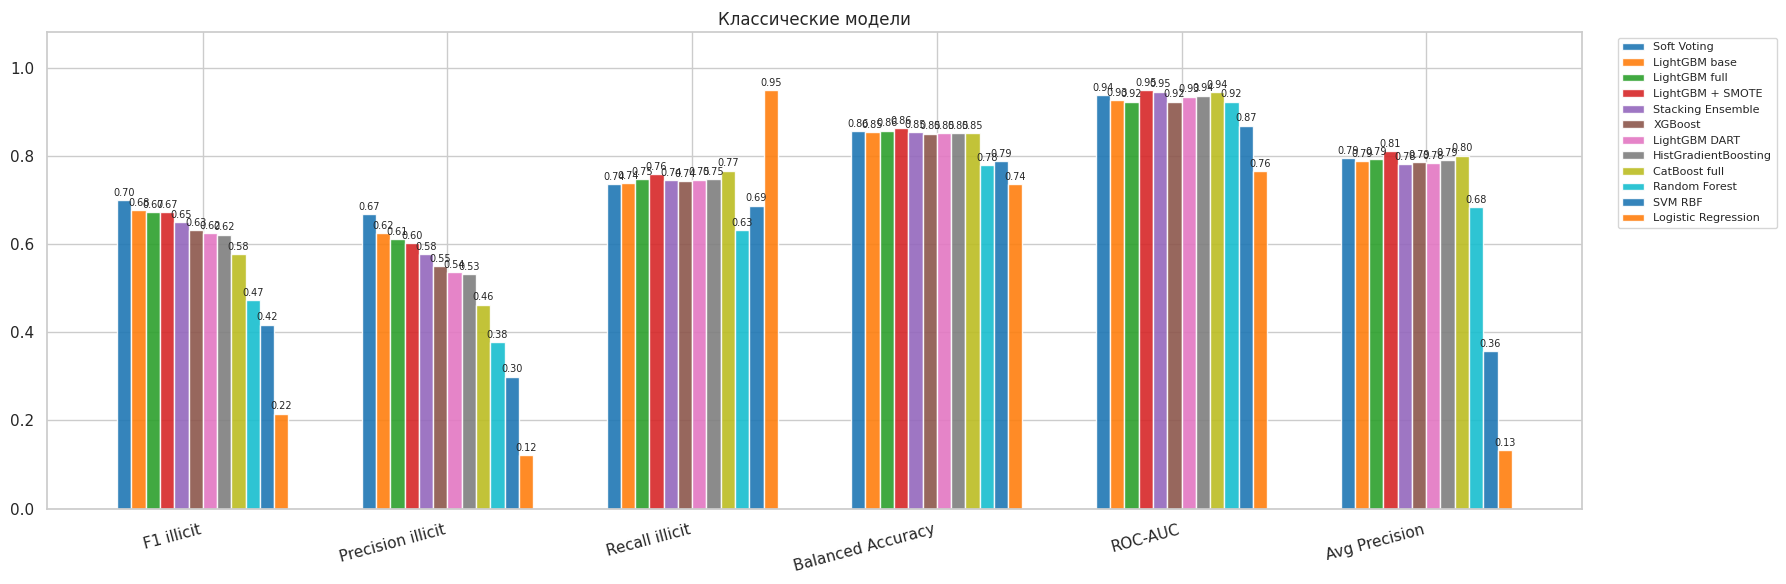

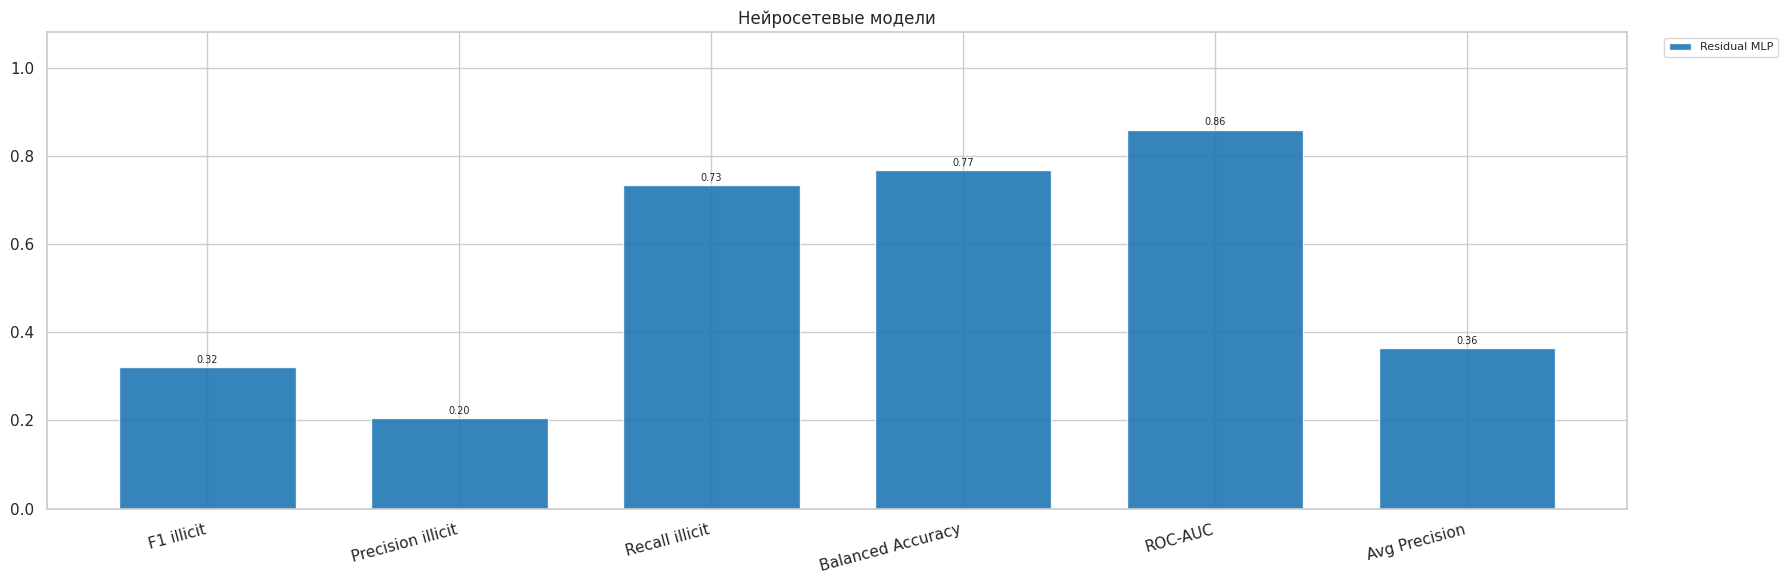

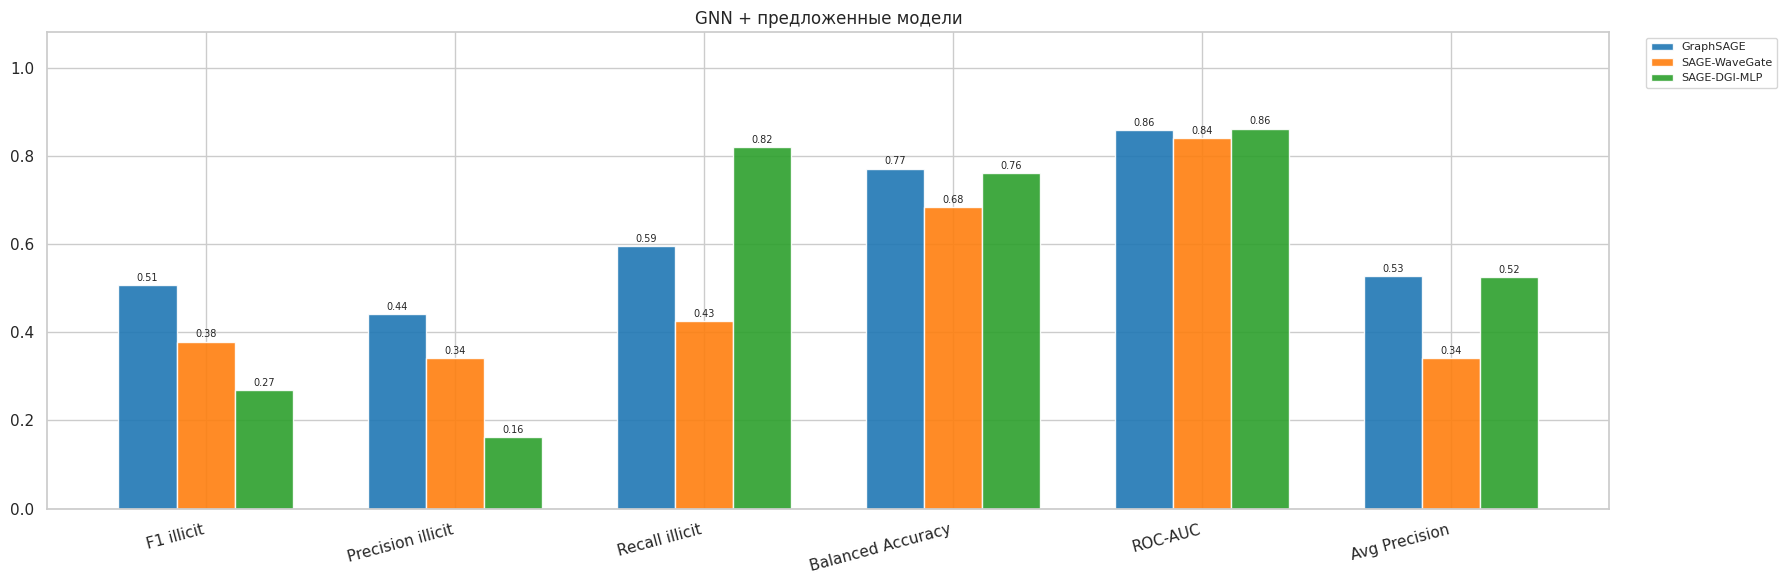

финальная таблица моделей


,model_name,family,threshold,f1_illicit,precision_illicit,recall_illicit,balanced_accuracy,roc_auc,average_precision
0,Soft Voting,classical,0.2705,0.7000,0.6675,0.7359,0.8552,0.9378,0.7945
1,LightGBM base,lightgbm,0.1091,0.6768,0.6245,0.7387,0.8539,0.9270,0.7889
2,LightGBM full,lightgbm,0.1325,0.6719,0.6106,0.7470,0.8569,0.9229,0.7926
3,LightGBM + SMOTE,classical,0.1519,0.6716,0.6022,0.7590,0.8621,0.9493,0.8108
4,Stacking Ensemble,classical,0.9653,0.6497,0.5765,0.7442,0.8531,0.9454,0.7805
5,XGBoost,classical,0.1381,0.6316,0.5491,0.7433,0.8504,0.9228,0.7857
6,LightGBM DART,lightgbm,0.1851,0.6244,0.5369,0.7461,0.8507,0.9342,0.7839
7,HistGradientBoosting,classical,0.0777,0.6214,0.5315,0.7479,0.8511,0.9363,0.7904
8,CatBoost full,catboost,0.0833,0.5768,0.4624,0.7664,0.8522,0.9447,0.8002
9,GraphSAGE,gnn,0.9107,0.5065,0.4411,0.5946,0.7711,0.8585,0.5279


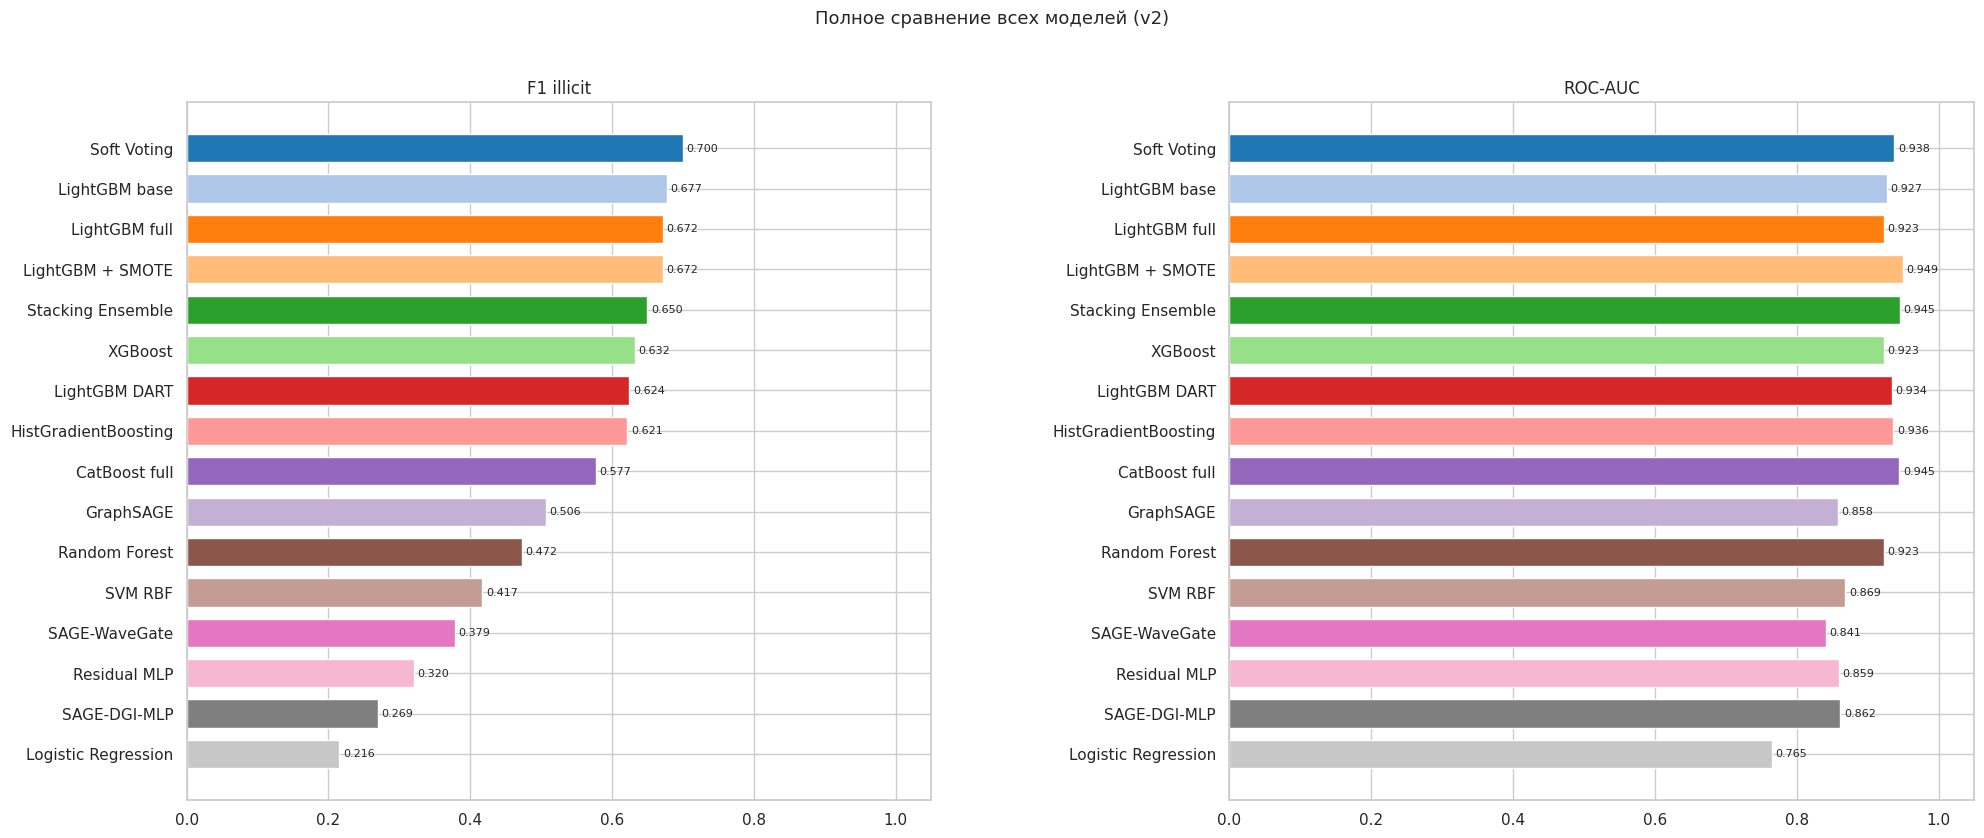

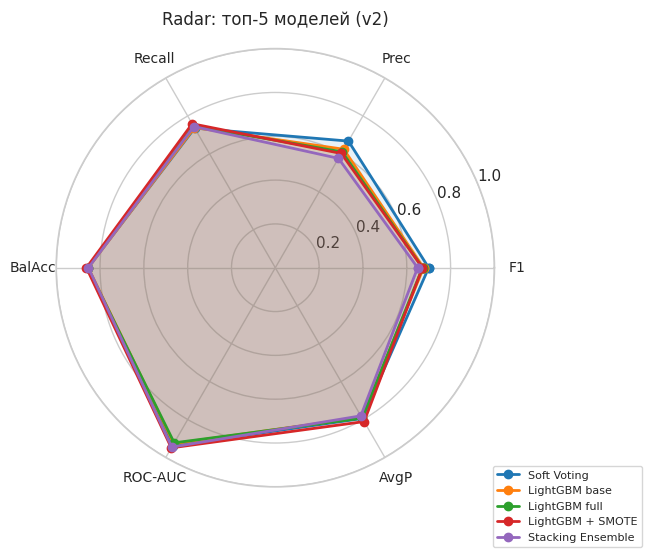

лучшая модель: Soft Voting
f1_illicit=0.7000
precision_illicit=0.6675
recall_illicit=0.7359
roc_auc=0.9378


In [50]:
# список METRICS_TO_PLOT задает общий набор метрик для сравнения всех семейств моделей.
METRICS_TO_PLOT = [
    ("f1_illicit", "F1 illicit"),
    ("precision_illicit", "Precision illicit"),
    ("recall_illicit", "Recall illicit"),
    ("balanced_accuracy", "Balanced Accuracy"),
    ("roc_auc", "ROC-AUC"),
    ("average_precision", "Avg Precision"),
]


# вход: таблица результатов; выход: сгруппированный barplot по ключевым метрикам.
def grouped_bar_chart(results_df: pd.DataFrame, title: str, fname: str):
    if results_df is None or len(results_df) == 0:
        print(f"нет данных для графика: {title}")
        return

    results_df = normalize_result_columns(results_df.copy())
    n_models = len(results_df)
    n_metrics = len(METRICS_TO_PLOT)
    x_pos = np.arange(n_metrics)
    width = 0.7 / max(n_models, 1)
    palette = sns.color_palette("tab10", n_colors=n_models)

    fig, ax = plt.subplots(figsize=(18, 6))
    for idx, (_, row) in enumerate(results_df.iterrows()):
        values = [float(row.get(metric, 0) or 0) for metric, _ in METRICS_TO_PLOT]
        bars = ax.bar(
            x_pos + idx * width - (n_models - 1) * width / 2,
            values,
            width=width,
            label=row["model_name"],
            color=palette[idx],
            alpha=0.9,
            edgecolor="white",
        )
        for bar, value in zip(bars, values):
            if value > 0.01:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([label for _, label in METRICS_TO_PLOT], rotation=15, ha="right")
    ax.set_ylim(0, 1.08)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.3)
    render_figure(fig, fname)


# classical_frames объединяет базовые модели, бустинги и ансамбли в одну итоговую таблицу.
classical_frames = [df_classical, df_lgb, df_cat]
extras = [result for result in [r_smote, r_stack, r_vote] if result is not None]
if extras:
    classical_frames.append(pd.DataFrame(extras))
classical_results_df = pd.concat(
    [normalize_result_columns(frame) for frame in classical_frames if frame is not None and len(frame)],
    ignore_index=True,
).sort_values("f1_illicit", ascending=False)

if "neural_results_df" not in globals():
    neural_results_df = pd.DataFrame()
if "gnn_results_df" not in globals():
    gnn_results_df = pd.DataFrame()

grouped_bar_chart(classical_results_df, "Классические модели", "compare_classical_v2.png")
if len(neural_results_df) > 0:
    grouped_bar_chart(neural_results_df, "Нейросетевые модели", "compare_neural_v2.png")
if len(gnn_results_df) > 0:
    grouped_bar_chart(gnn_results_df, "GNN + предложенные модели", "compare_gnn_v2.png")

frames = [classical_results_df]
if len(neural_results_df) > 0:
    frames.append(normalize_result_columns(neural_results_df))
if len(gnn_results_df) > 0:
    frames.append(normalize_result_columns(gnn_results_df))

all_results_df = (
    pd.concat(frames, ignore_index=True)
    .sort_values("f1_illicit", ascending=False)
    .reset_index(drop=True)
)

# baseline_row оставляет старый результат как контрольную точку для сравнения с canonical split.
baseline_row = pd.DataFrame([{
    "model_name": "old best broken split",
    "family": "baseline",
    "threshold": 0.2125,
    "f1_illicit": 0.0745,
    "precision_illicit": 0.0452,
    "recall_illicit": 0.2130,
    "balanced_accuracy": 0.5481,
    "roc_auc": 0.7445,
    "average_precision": 0.0531,
}])
all_results_with_baseline_df = pd.concat([all_results_df, baseline_row], ignore_index=True)

print("финальная таблица моделей")
display(all_results_with_baseline_df)
save_frame(all_results_df, "all_model_results_v2.csv")

palette_all = sns.color_palette("tab20", n_colors=len(all_results_df))
fig, axes = plt.subplots(1, 2, figsize=(20, max(6, len(all_results_df) * 0.45 + 1)))

for ax, (col, label) in zip(axes, [("f1_illicit", "F1 illicit"), ("roc_auc", "ROC-AUC")]):
    bars = ax.barh(
        all_results_df["model_name"],
        all_results_df[col].fillna(0),
        color=palette_all,
        edgecolor="white",
        height=0.7,
    )
    for bar, value in zip(bars, all_results_df[col].fillna(0)):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}",
            va="center",
            fontsize=8,
        )
    ax.set_title(label)
    ax.set_xlim(0, 1.05)
    ax.invert_yaxis()

fig.suptitle("Полное сравнение всех моделей (v2)", fontsize=13, y=1.02)
fig.tight_layout()
fig.subplots_adjust(wspace=0.4)
render_figure(fig, "all_models_comparison_v2.png")

top5 = all_results_df.head(5).copy()
radar_metrics = [metric for metric, _ in METRICS_TO_PLOT]
labels_r = ["F1", "Prec", "Recall", "BalAcc", "ROC-AUC", "AvgP"]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
palette_radar = sns.color_palette("tab10", n_colors=len(top5))

fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for idx, (_, row) in enumerate(top5.iterrows()):
    values = [float(row.get(metric, 0) or 0) for metric in radar_metrics]
    values += values[:1]
    ax_r.plot(angles, values, "-o", linewidth=2, color=palette_radar[idx], label=row["model_name"])
    ax_r.fill(angles, values, alpha=0.10, color=palette_radar[idx])

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(labels_r, fontsize=10)
ax_r.set_ylim(0, 1)
ax_r.set_title("Radar: топ-5 моделей (v2)", pad=18)
ax_r.legend(loc="lower right", bbox_to_anchor=(1.35, -0.15), fontsize=8)
fig_r.tight_layout()
render_figure(fig_r, "radar_top5_v2.png")

best = all_results_df.iloc[0]
print(f"лучшая модель: {best['model_name']}")
print(f"f1_illicit={best['f1_illicit']:.4f}")
print(f"precision_illicit={best['precision_illicit']:.4f}")
print(f"recall_illicit={best['recall_illicit']:.4f}")
print(f"roc_auc={best['roc_auc']:.4f}")

## 14 — precision-recall curves

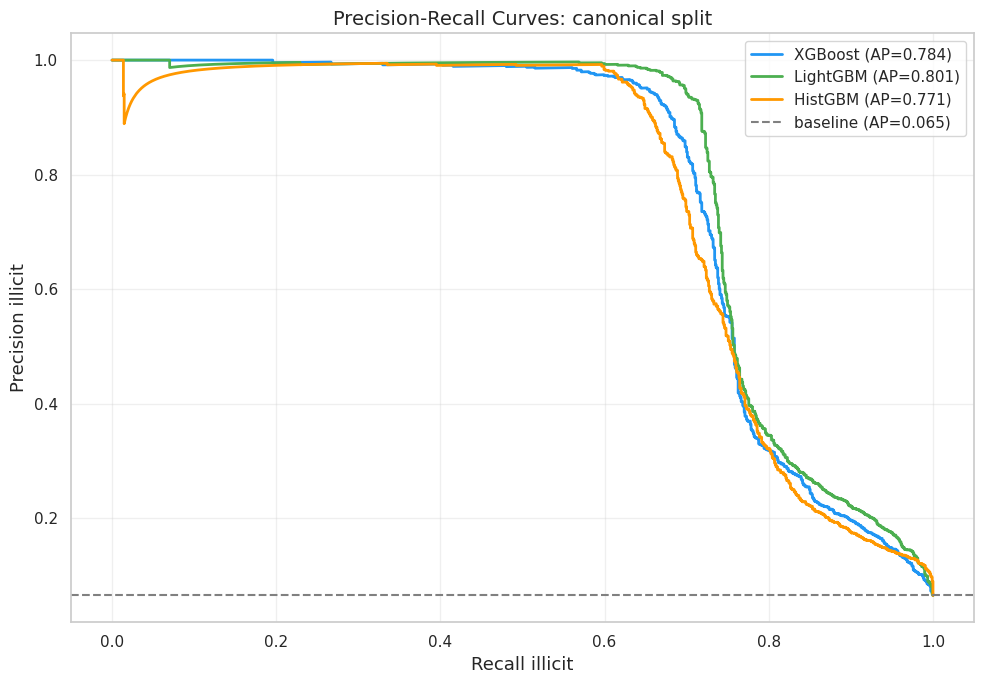

сохранено: pr_curves_improved.png


In [51]:
# вход: признаки; выход: precision-recall curves для сильных моделей на test-части.
def plot_pr_curves(feature_cols, save_path="pr_curves_improved.png"):
    x_tr, y_tr = getxy(split.traindf, feature_cols)
    _, _ = getxy(split.valdf, feature_cols)
    x_test, y_test = getxy(split.testdf, feature_cols)

    scaler = StandardScaler()
    x_tr = scaler.fit_transform(x_tr)
    x_test = scaler.transform(x_test)

    fig, ax = plt.subplots(figsize=(10, 7))
    # plot_specs хранит модели, которые реально доступны в текущем окружении.
    plot_specs = []
    if XGB_AVAILABLE:
        plot_specs.append((
            "XGBoost",
            xgb.XGBClassifier(
                n_estimators=600,
                max_depth=7,
                learning_rate=0.04,
                scale_pos_weight=posw,
                verbosity=0,
                random_state=RANDOM_STATE,
            ),
        ))
    if LGB_AVAILABLE:
        plot_specs.append((
            "LightGBM",
            lgb.LGBMClassifier(
                n_estimators=800,
                learning_rate=0.03,
                max_depth=7,
                num_leaves=63,
                scale_pos_weight=posw,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ))
    plot_specs.append((
        "HistGBM",
        HistGradientBoostingClassifier(
            max_iter=400,
            learning_rate=0.04,
            max_depth=8,
            random_state=RANDOM_STATE,
        ),
    ))

    colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"]
    for (name, model), color in zip(plot_specs, colors):
        sample_weight = compute_sample_weight("balanced", y=y_tr)
        try:
            model.fit(x_tr, y_tr, sample_weight=sample_weight)
        except TypeError:
            model.fit(x_tr, y_tr)
        scores = model.predict_proba(x_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, scores)
        avg_precision = average_precision_score(y_test, scores)
        ax.plot(recall, precision, color=color, lw=2, label=f"{name} (AP={avg_precision:.3f})")

    baseline_ap = y_test.mean()
    ax.axhline(baseline_ap, color="gray", linestyle="--", label=f"baseline (AP={baseline_ap:.3f})")
    ax.set_xlabel("Recall illicit", fontsize=13)
    ax.set_ylabel("Precision illicit", fontsize=13)
    ax.set_title("Precision-Recall Curves: canonical split", fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    render_figure(fig, save_path)
    print(f"сохранено: {save_path}")


plot_pr_curves(FULL_FEATURE_COLS)

## итог

| изменение | эффект |
|----------|--------|
| canonical split | test содержит репрезентативную долю illicit |
| youden's j threshold | порог устойчивее к temporal shift |
| feature engineering | добавлены log, ratio и time признаки |
| classical models | восстановлены сильные табличные baseline |
| neural models | добавлен residual mlp |
| gnn models | возвращены graphsage, sage-dgi-mlp и sage-wavegate |
| final visualization | добавлены grouped bar, all models и radar top-5 |